# **Salifort Motors Employee Retention Prediction Model**

This notebook will be used to analyze Human Resources (HR) data from Salifort Motors to identify trends that may help predict whether or not an employee is likely to leave the company. After performing the EDA of the dataset, we will be classification models to predict whether or not an employee will stay or leave, and assess the best fit.

Data Dictionary

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

### Import packages

In [1]:
# Import operational packages
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing and modeling
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer # check if this will be used

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV, train_test_split, PredefinedSplit # check if PredfinedSplit will be used
from sklearn.ensemble import RandomForestClassifier


import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

### Load dataset

In [3]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Perform EDA

In [6]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [8]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [10]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [12]:
# Rename columns as needed
df0 = df0.rename(columns={
    'satisfaction_level': 'satisfaction',
    'last_evaluation': 'last_eval',
    'average_montly_hours': 'avg_hrs_month',
    'time_spend_company': 'yrs_company',
    'Work_accident': 'work_accident',
    'left': 'left_company',
    'promotion_last_5years': 'promo_last_5yrs',
    'Department': 'department'
    
})


# Display all column names after the update
df0.columns

Index(['satisfaction', 'last_eval', 'number_project', 'avg_hrs_month',
       'yrs_company', 'work_accident', 'left_company', 'promo_last_5yrs',
       'department', 'salary'],
      dtype='object')

In [14]:
# Check for missing values
df0.isna().sum()

satisfaction       0
last_eval          0
number_project     0
avg_hrs_month      0
yrs_company        0
work_accident      0
left_company       0
promo_last_5yrs    0
department         0
salary             0
dtype: int64

In [16]:
# Check for duplicates
df0.duplicated().sum()

3008

In [18]:
# Inspect some rows containing duplicates
df0[df0.duplicated(keep=False)]

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,left_company,promo_last_5yrs,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [20]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df_clean = df0.drop_duplicates()


# Display first few rows of new dataframe as needed
df_clean.head()

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,left_company,promo_last_5yrs,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


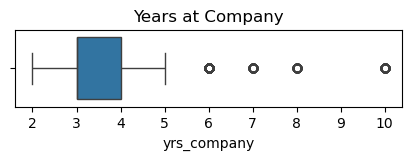

In [22]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
plt.figure(figsize=(5,1))
sns.boxplot(x=df_clean['yrs_company'])
plt.title('Years at Company')
plt.show()

In [24]:
# Determine the number of rows containing outliers

# Calculate the upper and lower bounds as
def calculate_outlier_bounds(values):
    iqr = values.quantile(0.75) - values.quantile(0.25)
    median = values.median()
    lower_bound = values.quantile(0.25) - 1.5 * iqr
    upper_bound = values.quantile(0.75) + 1.5 * iqr
    
    return iqr, median, lower_bound, upper_bound

In [26]:
def outlier_counts(values):
    if not pd.api.types.is_numeric_dtype(values): # only calculate for numeric values
        return [None]
    
    iqr, median, lower_bound, upper_bound = calculate_outlier_bounds(values)
    
    num_outliers = (values < lower_bound).sum() + (values > upper_bound).sum()
    
    return num_outliers
    
# Apply the function to each column
outliers = df_clean.apply(outlier_counts)

print(f"Number of outliers, satisfaction: {outliers['satisfaction']}\n"
      f"Number of outliers, last_eval: {outliers['last_eval']}\n"
      f"Number of outliers, number_project: {outliers['number_project']}\n"
      f"Number of outliers, avg_hrs_month: {outliers['avg_hrs_month']}\n"
      f"Number of outliers, yrs_company: {outliers['yrs_company']}\n"
      f"Number of outliers, work_accident: {outliers['work_accident']}\n"
      f"Number of outliers, left_company: {outliers['left_company']}\n"
      f"Number of outliers, promo_last_5yrs: {outliers['promo_last_5yrs']}\n"
      f"Number of outliers, department: {outliers['department']}\n"
      f"Number of outliers, salary: {outliers['salary']}\n"
     )

Number of outliers, satisfaction: 0
Number of outliers, last_eval: 0
Number of outliers, number_project: 0
Number of outliers, avg_hrs_month: 0
Number of outliers, yrs_company: 824
Number of outliers, work_accident: 1850
Number of outliers, left_company: 1991
Number of outliers, promo_last_5yrs: 203
Number of outliers, department: [None]
Number of outliers, salary: [None]



In [28]:
# Get numbers of people who left vs. stayed
print(f"Number of employees who left the company: {(df_clean['left_company'] == 1).sum()}\n"
      f"Number of employees who stayed at the company: {(df_clean['left_company'] == 0).sum()}\n"
     )

# Get percentages of people who left vs. stayed
print(f"Percentage of employees who left the company: {((df_clean['left_company'] == 1).sum() / (df_clean['left_company'].count()) * 100): .2f}\n"
      f"Perecentage of employees who stayed at the company: {((df_clean['left_company'] == 0).sum() / (df_clean['left_company'].count()) * 100): .2f}\n"
     )

Number of employees who left the company: 1991
Number of employees who stayed at the company: 10000

Percentage of employees who left the company:  16.60
Perecentage of employees who stayed at the company:  83.40



### Create visualizations

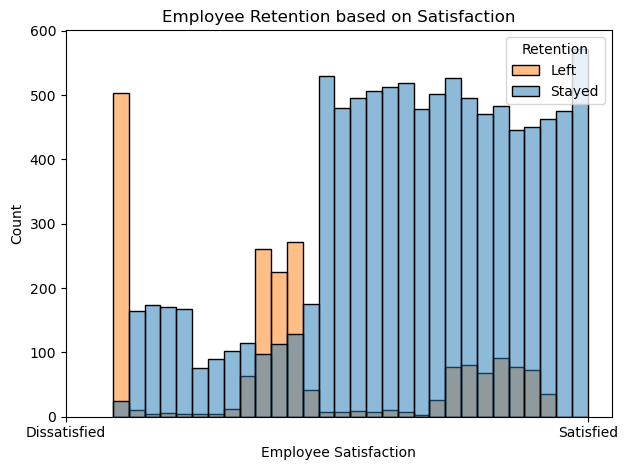

In [31]:
# Plot employee retention based on satisfaction
sns.histplot(
    data=df_clean,
    x='satisfaction',
    hue='left_company',
    bins=30,
    alpha=0.5,
    multiple='layer'
)

plt.xticks([0, 1], ['Dissatisfied', 'Satisfied'])
plt.legend(title='Retention', labels=['Left', 'Stayed'])

plt.xlabel('Employee Satisfaction')
plt.ylabel('Count')
plt.title('Employee Retention based on Satisfaction')

plt.tight_layout()
plt.show()

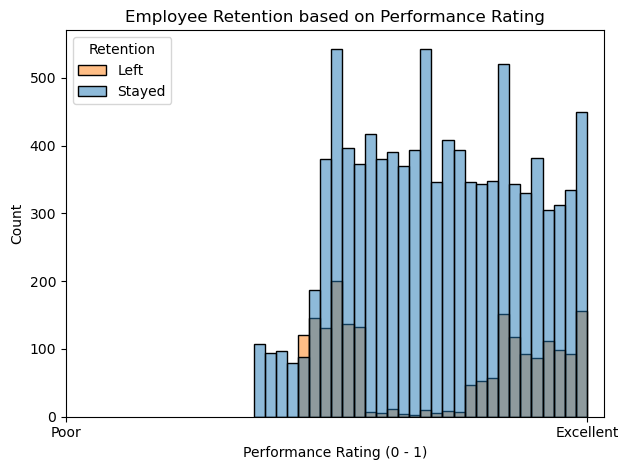

In [33]:
# Plot employee retention based on performance rating
sns.histplot(
    data=df_clean,
    x='last_eval',
    hue='left_company',
    bins=30,
    alpha=0.5,
    multiple='layer'
)

plt.xticks([0, 1], ['Poor', 'Excellent'])
plt.legend(title='Retention', labels=['Left', 'Stayed'])

plt.xlabel('Performance Rating (0 - 1)')
plt.ylabel('Count')
plt.title('Employee Retention based on Performance Rating')

plt.tight_layout()
plt.show()

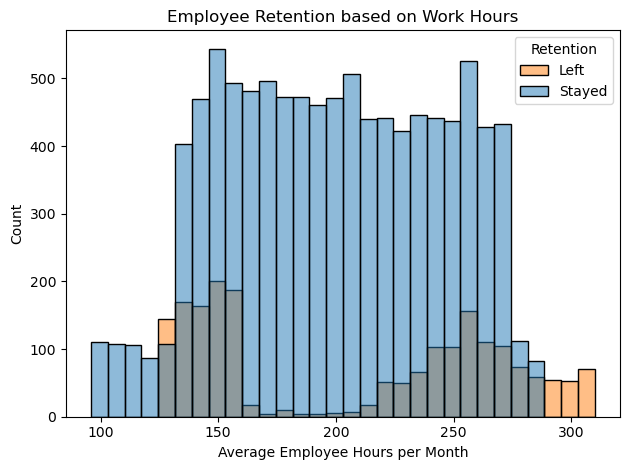

In [35]:
# Plot employee retention based on average hours worked
sns.histplot(
    data=df_clean,
    x='avg_hrs_month',
    hue='left_company',
    bins=30,
    alpha=0.5,
    multiple='layer'
)

plt.legend(title='Retention', labels=['Left', 'Stayed'])

plt.xlabel('Average Employee Hours per Month')
plt.ylabel('Count')
plt.title('Employee Retention based on Work Hours')

plt.tight_layout()
plt.show()

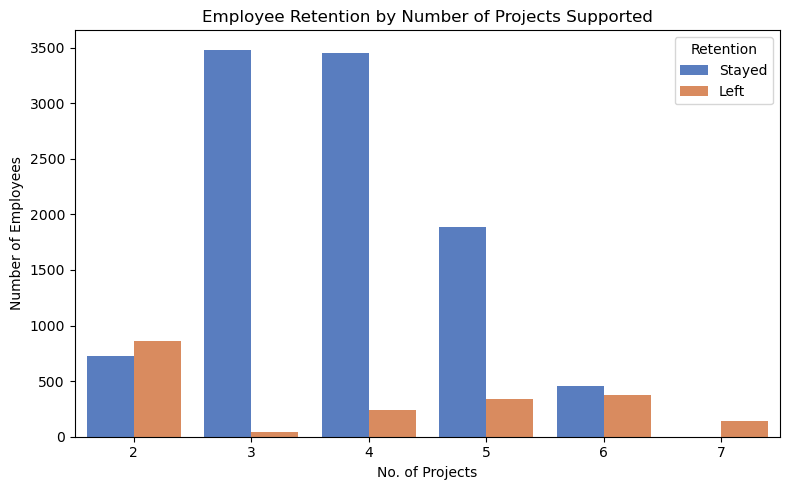

In [37]:
# Plot employee retention based on number of projects supported
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x='number_project',
    hue='left_company',
    palette='muted'
)

plt.legend(title='Retention', labels=['Stayed', 'Left'])
plt.xlabel('No. of Projects')
plt.ylabel('Number of Employees')
plt.title('Employee Retention by Number of Projects Supported')
plt.tight_layout()
plt.show()

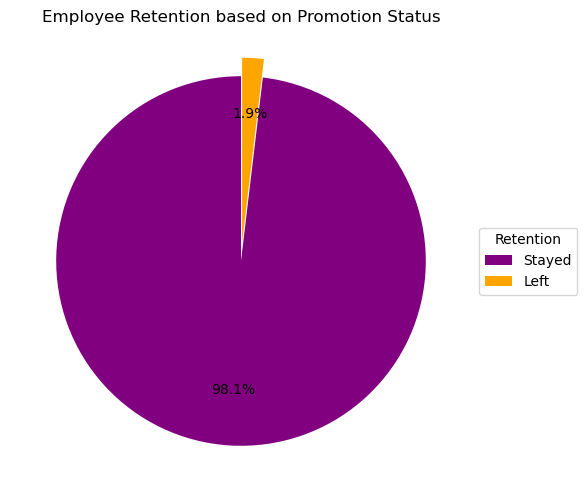

In [39]:
# Plot employee retetion based on promotion status for the last 5 years 
df_5yrs = df_clean[df_clean['yrs_company'] >= 5]
retention_by_promo = df_5yrs.groupby('left_company', dropna=True)['promo_last_5yrs'].sum()

colors = ['purple', 'orange']
explode = [0.1 if label == 1 else 0 for label in retention_by_promo.index] # explode the percentage of employees who left

plt.figure(figsize=(6,6))
patches, texts, autotexts = plt.pie(
    retention_by_promo,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    pctdistance=0.7,
    startangle=90
)

plt.legend(patches, ['Stayed', 'Left'], title="Retention", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Employee Retention based on Promotion Status')
plt.show()

In [41]:
# Plot the percentage of employees who left by department
ee_per_dept = (
    df_clean
    .groupby('department', dropna=True)
    .size()
    .rename('total_employees')
)

left_per_dept = (
    df_clean[df_clean['left_company'] == 1]
    .groupby('department', dropna=True)
    .size()
    .rename('employees_left')
)

retention_by_dept = pd.concat([ee_per_dept, left_per_dept], axis=1).reset_index()
retention_by_dept['pct_left'] = retention_by_dept['employees_left'] / retention_by_dept['total_employees']

retention_by_dept.sort_values('pct_left', ascending=False)

,department,total_employees,employees_left,pct_left
3,hr,601,113,0.188020
2,accounting,621,109,0.175523
9,technical,2244,390,0.173797
8,support,1821,312,0.171334
7,sales,3239,550,0.169805
5,marketing,673,112,0.166419
0,IT,976,158,0.161885
6,product_mng,686,110,0.160350
1,RandD,694,85,0.122478
4,management,436,52,0.119266


C:\Users\Myesha\AppData\Local\Temp\ipykernel_46876\2403834958.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


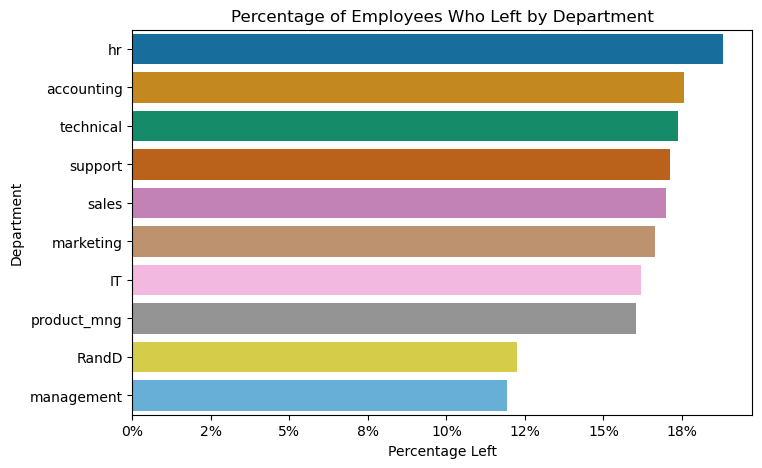

In [43]:
retention_sorted = retention_by_dept.sort_values('pct_left', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=retention_sorted,
    x='pct_left',
    y='department',
    palette="colorblind"
)

plt.xlabel('Percentage Left')
plt.ylabel('Department')
plt.title('Percentage of Employees Who Left by Department')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.show()

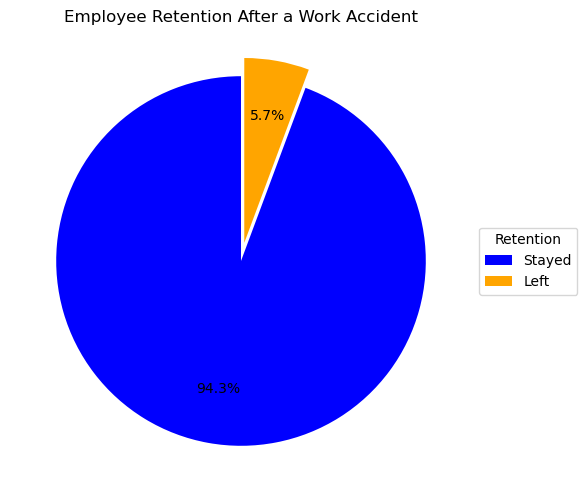

In [45]:
# Plot the percentages of employes who left after having a work accident
ee_work_acc = (
    df_clean.loc[df_clean['work_accident'] == 1, 'left_company']
    .value_counts()
    .sort_index()
)

colors = ['blue', 'orange']
explode = [0.1 if index == 1 else 0 for index in ee_work_acc.index] # explode the percentage of employees who left

plt.figure(figsize=(6,6))
patches, texts, autotexts = plt.pie(
    ee_work_acc,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    pctdistance=0.7,
    startangle=90
)

plt.legend(patches, ['Stayed', 'Left'], title="Retention", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Employee Retention After a Work Accident')
plt.show()

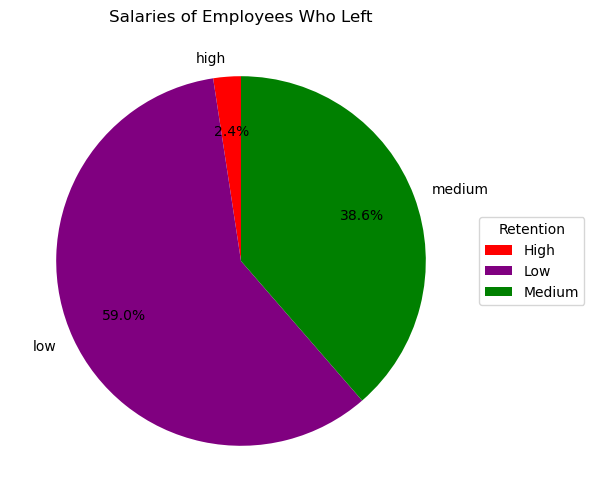

In [47]:
# Plot the distribution of salaries for employees who left
ee_left_salary = (
    df_clean.loc[df_clean['left_company'] == 1, 'salary']
    .value_counts()
    .sort_index()
)

colors = ['red', 'purple', 'green']
explode = [0.1 if index == 1 else 0 for index in ee_left_salary.index] # explode the percentage of employees who left

plt.figure(figsize=(6,6))
patches, texts, autotexts = plt.pie(
    ee_left_salary,
    labels=ee_left_salary.index,
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    pctdistance=0.7,
    startangle=90
)

plt.legend(patches, ['High', 'Low', 'Medium'], title="Retention", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Salaries of Employees Who Left')
plt.show()

There is a strong correlation between low job satisfaction and employees leaving the company. Looking at average hours worked per month, employee retention follows a normal distribution, but those who worked the most hours all appear to have left the company. Similarly, as the number of supported projects increases, so does the likelihood that the employee will leave. On a department level, the highest turnover is in HR (18.8%), with Accounting, Technical and Support following closely behind with turnover rates between 17.1% and 17.5%. Lastly, the majority of employees who left are in the "low" salary band.

There does not appear to be a strong correlation between performance rating, work accidents, or promotion status and retention.

The outcome variable for the models will be left_company. We'll explore 3 different types of models: a logistic regression, a Random Forest, and an XGBoost. For the logistic regression model, we'll ensure the following assumptions are met:

- Outcome variable is categorical
- Observations are independent of each other
- There is no severe multicollinearity among X variables
- There is a linear relationship between each X variable and the logit of the outcome variable

We will remove any extreme outliers for our logistic regression model and ensure class balance for the outcome variable. The data will be broken into training, test, and validation sets (60/20/20). For the Random Forest Model and XGBoost Model, we will use cross-validation to tune the hyperparameters using the training and validation data. Once a champion model has been determined, we'll evaluate it's performance using the test data.

In [50]:
df_clean.dtypes

satisfaction       float64
last_eval          float64
number_project       int64
avg_hrs_month        int64
yrs_company          int64
work_accident        int64
left_company         int64
promo_last_5yrs      int64
department          object
salary              object
dtype: object

left_company
0    83.39588
1    16.60412
Name: proportion, dtype: float64


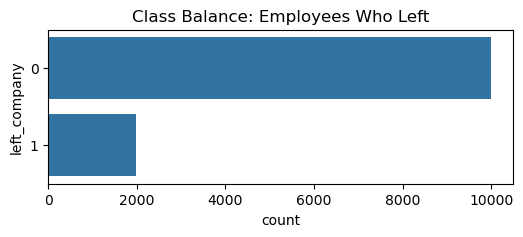

In [52]:
# Check class balance
print(df_clean['left_company'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,2))
sns.countplot(y='left_company', data=df_clean)
plt.title("Class Balance: Employees Who Left")
plt.show()

About 83.4% of the data represents employees who stayed at the company. The data will be resampled to create class balance in the outcome variable.

In [54]:
from sklearn.utils import resample

majority = df_clean[df_clean['left_company'] == 0]
minority = df_clean[df_clean['left_company'] == 1]

# Upsample the minority class
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

# Combine majority class with upsampled minority class
balanced = pd.concat([majority, minority_upsampled])

# Display new class counts
print(balanced['left_company'].value_counts(normalize=True) * 100)

left_company
0    50.0
1    50.0
Name: proportion, dtype: float64


In [56]:
balanced_num = balanced[['satisfaction', 'avg_hrs_month', 'number_project']]
balanced_cat = balanced[['department', 'salary']]

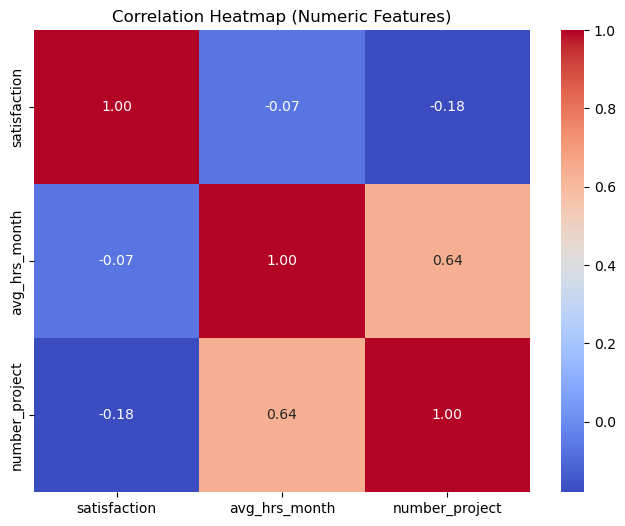

In [58]:
# Check for multicollinearity among X variables
plt.figure(figsize=(8, 6))
sns.heatmap(
    balanced_num.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

The heatmap confirms there is not strong multicollinearity between the features.

In [60]:
# Set variables
X = balanced.drop(columns=['left_company'])
y = balanced['left_company']

X.head()

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,promo_last_5yrs,department,salary
2000,0.58,0.74,4,215,3,0,0,sales,low
2001,0.82,0.67,2,202,3,0,0,sales,low
2002,0.45,0.69,5,193,3,0,0,sales,low
2003,0.78,0.82,5,247,3,0,0,sales,low
2004,0.49,0.60,3,214,2,0,0,sales,low


In [62]:
# Split the data into training and testing sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [64]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, 
                                            stratify=y_temp, random_state=42)

In [66]:
# Confirm the dimensions of the training, validation and testing sets
print(f"X_temp shape: {X_temp.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_temp shape: {y_temp.shape}")
print(f"y_test shape: {y_test.shape}")

print()

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_temp shape: (16000, 9)
X_test shape: (4000, 9)
y_temp shape: (16000,)
y_test shape: (4000,)

X_train shape: (12000, 9)
X_val shape: (4000, 9)
y_train shape: (12000,)
y_val shape: (4000,)


In [68]:
# Encoded the non-numerical features of the training data
encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train_to_encode = X_train[['department', 'salary']]
X_train_encoded = encoder.fit_transform(X_train_to_encode)

# Add encoded features to a dataframe
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out())

# Drop the encoded columns from the training dataframe
X_train_subset = X_train.drop(columns=['department', 'salary'])

# Concatenate `X_train_subset` and `X_train_encoded_df` to form the final dataframe for training data
X_train_final = pd.concat([X_train_subset.reset_index(drop=True), X_train_encoded_df], axis=1)

# Reassign changes to X_train
X_train = X_train_final

X_train.head()

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,promo_last_5yrs,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.73,0.99,5,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.40,0.53,2,158,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.68,0.57,3,197,3,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.09,0.93,6,271,4,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.94,0.57,3,166,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [70]:
# Encode the training outcome variable
le = LabelEncoder()

y_train = le.fit_transform(y_train)

y_train

array([1, 1, 0, ..., 0, 1, 0], dtype=int64)

In [72]:
# Encode the non-numerical features of the validation data
X_val_to_encode = X_val[['department', 'salary']]
X_val_encoded = encoder.fit_transform(X_val_to_encode)

# Add encoded features to a dataframe
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoder.get_feature_names_out())

# Drop the encoded columns from the training dataframe
X_val_subset = X_val.drop(columns=['department', 'salary'])

# Concatenate `X_train_subset` and `X_train_encoded_df` to form the final dataframe for training data
X_val_final = pd.concat([X_val_subset.reset_index(drop=True), X_val_encoded_df], axis=1)

# Reassign changes to X_train
X_val = X_val_final

X_val.head()

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,promo_last_5yrs,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.72,0.58,5,147,3,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.10,0.89,6,247,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.50,0.64,3,249,2,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.73,0.99,6,206,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.65,0.57,3,137,4,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [74]:
# Encode the validation outcome variable
y_val_final = le.fit_transform(y_val)
y_val = y_val_final

y_val

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

In [76]:
# Encode the non-numerical features of the test data
X_test_to_encode = X_test[['department', 'salary']]
X_test_encoded = encoder.fit_transform(X_test_to_encode)

# Add encoded features to a dataframe
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out())

# Drop the encoded columns from the training dataframe
X_test_subset = X_test.drop(columns=['department', 'salary'])

# Concatenate `X_train_subset` and `X_train_encoded_df` to form the final dataframe for training data
X_test_final = pd.concat([X_test_subset.reset_index(drop=True), X_test_encoded_df], axis=1)

# Reassign changes to X_train
X_test = X_test_final

X_test.head()

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,promo_last_5yrs,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.09,0.96,6,281,4,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.51,0.98,4,171,2,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.67,1.00,3,201,4,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.77,0.89,4,270,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.85,0.66,5,189,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [78]:
# Encode the test outcome variable
y_test_final = le.fit_transform(y_test)
y_test = y_test_final

y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

### **Create a Logistic Regression Model**

In [80]:
# Assign the test, validation, and training data to variables for the Random Forest Model
X_train_lr, X_val_lr, X_test_lr = X_train.copy(), X_val.copy(), X_test.copy()
y_train_lr, y_val_lr, y_test_lr = y_train.copy(), y_val.copy(), y_test.copy()

In [82]:
print(X_train_lr.shape)
print(y_train_lr.shape)

(12000, 18)
(12000,)


In [84]:
# Construct a logistic regression model and fit it to the training set
model = LogisticRegression(random_state=0, max_iter=1000).fit(X_train_lr, y_train_lr)

In [86]:
print(X_test_lr.shape)

(4000, 18)


In [88]:
# Display the predictions on the encoded testing set
y_pred_lr = model.predict(X_val_lr)

y_pred_lr

array([0, 1, 0, ..., 0, 1, 1], dtype=int64)

In [90]:
# Display the true labels of the testing set
y_val_lr

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

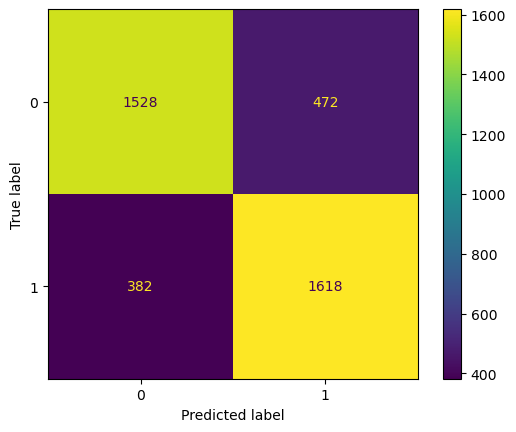

In [92]:
# Create a confusion matrix to visualize the results of the logistic regression model
cnf_matrix_lr = confusion_matrix(
    y_val_lr,
    y_pred_lr,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnf_matrix_lr,
    display_labels=model.classes_
)

disp.plot(values_format='d')

In [94]:
# Create a classification report to evaluate the performance of the model
target_labels = ['0', '1']
print(classification_report(y_val_lr, y_pred_lr, target_names=target_labels))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      2000
           1       0.77      0.81      0.79      2000

    accuracy                           0.79      4000
   macro avg       0.79      0.79      0.79      4000
weighted avg       0.79      0.79      0.79      4000



In [95]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
coefficients = model.coef_[0]
feature_names = X_train_lr.columns

coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

coeff_df

,Feature,Coefficient
0,satisfaction,-4.437753
1,last_eval,1.007806
2,number_project,-0.451029
3,avg_hrs_month,0.004696
4,yrs_company,0.656935
5,work_accident,-1.316201
6,promo_last_5yrs,-0.985808
7,department_RandD,-0.245282
8,department_accounting,0.134404
9,department_hr,0.220600


In [96]:
# Create a table of results to capture model performance
log_regression_results = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'F1':  [f1_score(y_val_lr, y_pred_lr)],
    'Recall': [recall_score(y_val_lr, y_pred_lr)],
    'Precision': [precision_score(y_val_lr, y_pred_lr)],
    'Accuracy': [accuracy_score(y_val_lr, y_pred_lr)]
})

log_regression_results

,Model,F1,Recall,Precision,Accuracy
0,Logistic Regression,0.791198,0.809,0.774163,0.7865


The logistic regression model correctly predicts employees who left 51% of the time, and users who stayed 51% of the time. The model's accuracy is 50.6%, and the recall score is 53.4%. With the largest magnitude coefficient at -4.43, satisfaction is the biggest indicator of whether an employee would leave, as expected.

Next, we'll create tree models to predict whether an employee will stay or leave.

### **Create a Random Forest Model**

In [99]:
# Assign the test, validation, and training data to variables for the Random Forest Model
X_train_rf, X_val_rf, X_test_rf = X_train.copy(), X_val.copy(), X_test.copy()
y_train_rf, y_val_rf, y_test_rf = y_train.copy(), y_val.copy(), y_test.copy()

In [100]:
X_train_rf.head()

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,promo_last_5yrs,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.73,0.99,5,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.40,0.53,2,158,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.68,0.57,3,197,3,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.09,0.93,6,271,4,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.94,0.57,3,166,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [101]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [2,3,4,5, None], 
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'max_features': [2,3,4],
             'n_estimators': [75, 100, 125, 150]
             }  

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall', n_jobs = -1, verbose = 1)

In [102]:
%%time

### Fit the model to the data 
rf_cv.fit(X_train_rf, y_train_rf)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
CPU times: total: 31.9 s
Wall time: 18min 19s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, None],
                         'max_features': [2, 3, 4],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [75, 100, 125, 150]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'],
             verbose=1)

In [103]:
# Examine best recall score
rf_cv.best_score_

0.9913333333333334

In [104]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 150}

In [105]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_pred_rf = rf_cv.best_estimator_.predict(X_val_rf)

y_pred_rf

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

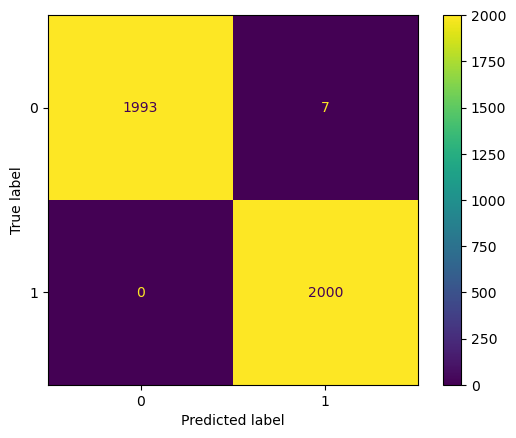

In [106]:
# Create a confusion matrix to visualize the results of the random forest model
cnf_matrix_rf = confusion_matrix(
    y_val_rf,
    y_pred_rf,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnf_matrix_rf,
    display_labels=model.classes_
)

disp.plot(values_format='d')

In [107]:
# Create a classification report to evaluate the performance of the model
target_labels = ['0', '1']
print(classification_report(y_val_rf, y_pred_rf, target_names=target_labels))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [108]:
# Create a table of results to capture model performance
rf_cv_results = pd.DataFrame({
    'Model': ['Random Forest'],
    'F1':  [f1_score(y_val_rf, y_pred_rf)],
    'Recall': [recall_score(y_val_rf, y_pred_rf)],
    'Precision': [precision_score(y_val_rf, y_pred_rf)],
    'Accuracy': [accuracy_score(y_val_rf, y_pred_rf)]
})

rf_cv_results

,Model,F1,Recall,Precision,Accuracy
0,Random Forest,0.998253,1.0,0.996512,0.99825


The model predicted 99.8% of the data points correctly. It predicted 7 false positives and no false negatives.

### **Create an XGBoost Model**

In [111]:
# Assign the test, validation, and training data to variables for the XGBoost Model
X_train_xgb, X_val_xgb, X_test_xgb = X_train.copy(), X_val.copy(), X_test.copy()
y_train_xgb, y_val_xgb, y_test_xgb = y_train.copy(), y_val.copy(), y_test.copy()

In [112]:
X_train_xgb.head()

,satisfaction,last_eval,number_project,avg_hrs_month,yrs_company,work_accident,promo_last_5yrs,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.73,0.99,5,241,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.40,0.53,2,158,3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.68,0.57,3,197,3,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.09,0.93,6,271,4,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.94,0.57,3,166,4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [113]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42) 

cv_params_xgb = {'max_depth': [4,5,10], 
             'min_child_weight': [3,5],
             'learning_rate': [0.2, 0.3],
             'n_estimators': [5, 10, 20],
             'subsample': [0.7],
             'colsample_bytree': [0.7]
             } 

# Define a list of scoring metrics to capture
scoring_xgb = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params_xgb, scoring=scoring_xgb, cv=5, refit='recall', n_jobs = -1, verbose = 1)

In [114]:
%%time

# Fit the model to the data
xgb_cv.fit(X_train_xgb, y_train_xgb)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
CPU times: total: 2.16 s
Wall time: 12.5 s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7], 'learning_rate': [0.2, 0.3],
                         'max_depth': [4, 5, 10], 'min_child_weight': [3, 5],
                         'n_estimators': [5, 10, 20], 'subsample': [0.7]},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'],
             verbose=1)

In [115]:
# Examine best recall score
xgb_cv.best_score_

0.9641666666666667

In [116]:
# Examine best parameters
xgb_cv.best_params_

{'colsample_bytree': 0.7,
 'learning_rate': 0.3,
 'max_depth': 10,
 'min_child_weight': 3,
 'n_estimators': 20,
 'subsample': 0.7}

In [117]:
# Access the GridSearch results and convert it to a pandas df
### YOUR CODE HERE ###
xgb_cv_results_df = pd.DataFrame(xgb_cv.cv_results_)
xgb_cv_results_df.columns

# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_cv_results_df['mean_test_precision'][xgb_cv.best_index_]

0.9865351807349537

In [118]:
# Use the best estimator to predict on the validation data
y_pred_xgb = xgb_cv.best_estimator_.predict(X_val_xgb)

y_pred_xgb

array([0, 1, 0, ..., 1, 0, 1])

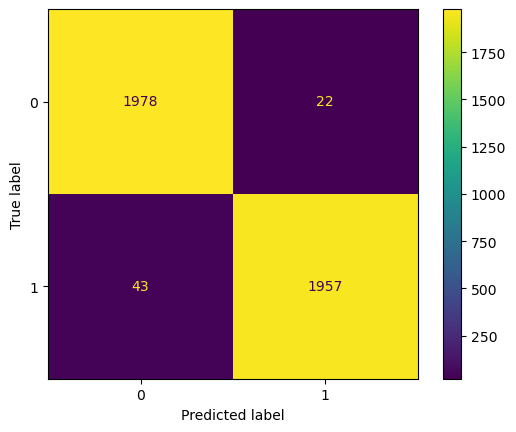

In [119]:
# Create a confusion matrix to visualize the results of the XGBoost model
cnf_matrix_xgb = confusion_matrix(
    y_val_xgb,
    y_pred_xgb,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnf_matrix_xgb,
    display_labels=model.classes_
)

disp.plot(values_format='d')

In [120]:
# Create a classification report
print(classification_report(y_val_xgb, y_pred_xgb, target_names=target_labels))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2000
           1       0.99      0.98      0.98      2000

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



In [121]:
# Create a table of results to capture model performance
xgb_cv_results = pd.DataFrame({
    'Model': ['XGBoost'],
    'F1':  [f1_score(y_val_xgb, y_pred_xgb)],
    'Recall': [recall_score(y_val_xgb, y_pred_xgb)],
    'Precision': [precision_score(y_val_xgb, y_pred_xgb)],
    'Accuracy': [accuracy_score(y_val_xgb, y_pred_xgb)]
})

xgb_cv_results

,Model,F1,Recall,Precision,Accuracy
0,XGBoost,0.983664,0.9785,0.988883,0.98375


**Use the Champion Model to predict on test data**

In [123]:
champ_cv_results = pd.concat([log_regression_results, rf_cv_results, xgb_cv_results], ignore_index=True)

champ_cv_results

,Model,F1,Recall,Precision,Accuracy
0,Logistic Regression,0.791198,0.8090,0.774163,0.78650
1,Random Forest,0.998253,1.0000,0.996512,0.99825
2,XGBoost,0.983664,0.9785,0.988883,0.98375


While the results of both models are similar, the Random Forest Model performed a little better than the XGBoost Model.

In [125]:
y_pred_champ = rf_cv.best_estimator_.predict(X_test_rf)

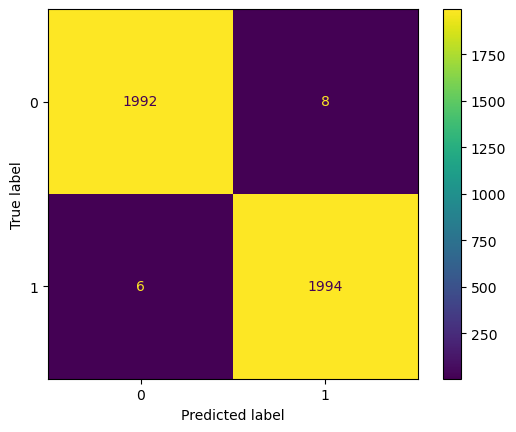

In [126]:
# Create a confusion matrix to visualize the results of the champion model
cnf_matrix_champ = confusion_matrix(
    y_test_rf,
    y_pred_champ,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cnf_matrix_champ,
    display_labels=model.classes_
)

disp.plot(values_format='d')

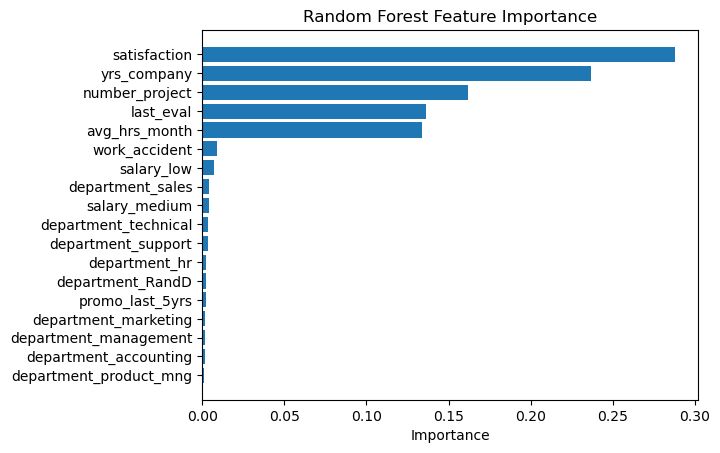

In [127]:
# Evaluate the feature importances of champion model
importances = rf_cv.best_estimator_.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

The most important features were satisfaction and years at the company. This is an expected result as we saw in previous charts there is a strong correlation between satisfaction and retention..

The model has high scores on all metrics - precision, recall, accuracy, and F1. Given that it successfully predicts whether a video represents a claim or an opinion based on user engagement, I would recommend this model to predict whether an employee is likely to leave, as well as hone in on the factors influencing that decision.